In [1]:
import requests
import pandas as pd

url = "https://energy.ec.europa.eu/document/download/906e60ca-8b6a-44e7-8589-652854d2fd3f_en?filename=Weekly_Oil_Bulletin_Prices_History_maticni_4web.xlsx"

response = requests.get(url, timeout=30)
response.raise_for_status()

filename = "Weekly_Oil_Bulletin_Prices_History_maticni_4web.xlsx"

with open(filename, "wb") as f:
    f.write(response.content)

print("Download successful")
print("Status code:", response.status_code)
print("File size:", len(response.content), "bytes")

xls = pd.ExcelFile(filename)
print("Sheets:", xls.sheet_names)


file = "Weekly_Oil_Bulletin_Prices_History_maticni_4web.xlsx"

df = pd.read_excel(file, sheet_name="Prices with taxes", skiprows=[1])

print(df.head())
print(df.columns.tolist()[:15])

Download successful
Status code: 200
File size: 4386046 bytes
Sheets: ['Prices with taxes', 'Prices wo taxes', 'Consumption', 'VAT', 'Excise duties', 'Excise duties - components', 'Other Indirect Taxes']
  Consumer prices of petroleum products inclusive of duties and taxes  CTR  \
0                                               Date                   NaN   
1                                2026-04-20 00:00:00                   EU_   
2                                2026-04-13 00:00:00                   EU_   
3                                2026-04-06 00:00:00                   EU_   
4                                2026-03-30 00:00:00                   EU_   

  EU_price_with_tax_euro95 EU_price_with_tax_diesel  \
0                   1000 l                   1000 l   
1              1827.359765              2007.671738   
2              1853.723723              2099.719327   
3              1878.734029              2112.274655   
4              1871.508517              2075.661431 

In [8]:
import os
print(os.listdir())
!python download.py

['.ipynb_checkpoints', 'clean.py', 'download.py', 'proof.ipynb', 'Weekly_Oil_Bulletin_Prices_History_maticni_4web.xlsx']
Download successful
Status code: 200
File size: 4386046 bytes
Saved as: Weekly_Oil_Bulletin_Prices_History_maticni_4web.xlsx


In [11]:
!python clean.py

Sheets: ['Prices with taxes', 'Prices wo taxes', 'Consumption', 'VAT', 'Excise duties', 'Excise duties - components', 'Other Indirect Taxes']
        Date  CTR  ...  UK_price_with_tax_fuel_oil_2  UK_price_with_tax_LPG
0 2026-04-20  NaN  ...                           NaN                    NaN
1 2026-04-13  NaN  ...                           NaN                    NaN
2 2026-04-06  NaN  ...                           NaN                    NaN
3 2026-03-30  NaN  ...                           NaN                    NaN
4 2026-03-23  NaN  ...                           NaN                    NaN

[5 rows x 226 columns]
['Date', 'CTR', 'EU_price_with_tax_euro95', 'EU_price_with_tax_diesel', 'EU_price_with_tax_heEUing_oil', 'EU_price_with_tax_fuel_oil_1', 'EU_price_with_tax_fuel_oil_2', 'EU_price_with_tax_LPG', 'CTR.1', 'EUR_price_with_tax_euro95', 'EUR_price_with_tax_diesel', 'EUR_price_with_tax_heEURing_oil', 'EUR_price_with_tax_fuel_oil_1', 'EUR_price_with_tax_fuel_oil_2', 'EUR_price_with_

In [13]:
!python reshape.py

         Date country fuel_type price_type  price_per_1000l
0  2026-04-20      EU    euro95   with_tax      1827.359765
1  2026-04-13      EU    euro95   with_tax      1853.723723
2  2026-04-06      EU    euro95   with_tax      1878.734029
3  2026-03-30      EU    euro95   with_tax      1871.508517
4  2026-03-23      EU    euro95   with_tax      1893.491227
5  2026-03-16      EU    euro95   with_tax      1837.926054
6  2026-03-09      EU    euro95   with_tax      1774.084779
7  2026-03-02      EU    euro95   with_tax      1664.651018
8  2026-02-23      EU    euro95   with_tax      1637.231143
9  2026-02-16      EU    euro95   with_tax      1631.953053
(63780, 5)
Long file saved as prices_with_taxes_long.csv


In [28]:
!python analysis.py

In [22]:
fuel_df.head()


,Date,EU_price_with_tax_euro95,EU_price_with_tax_diesel,EUR_price_with_tax_euro95,EUR_price_with_tax_diesel,AT_price_with_tax_euro95,AT_price_with_tax_diesel,BE_price_with_tax_euro95,BE_price_with_tax_diesel,BG_price_with_tax_euro95,...,RO_price_with_tax_euro95,RO_price_with_tax_diesel,SE_price_with_tax_euro95,SE_price_with_tax_diesel,SI_price_with_tax_euro95,SI_price_with_tax_diesel,SK_price_with_tax_euro95,SK_price_with_tax_diesel,UK_price_with_tax_euro95,UK_price_with_tax_diesel
0,2026-04-20,1827.359765,2007.671738,1890.852211,2067.790143,1691.0,1948.0,1834.52,2193.10,1470.1,...,1618.148810,1814.207146,1716.209314,2017.086874,1646.52,1874.21,1694.0,1772.0,NaN,NaN
1,2026-04-13,1853.723723,2099.719327,1915.431289,2154.223347,1718.0,2075.0,1874.94,2326.01,1470.1,...,1749.560267,1915.409986,1712.265883,2129.360999,1634.76,1852.15,1669.0,1750.0,NaN,NaN
2,2026-04-06,1878.734029,2112.274655,1945.947463,2158.252964,1787.0,2228.0,1896.50,2309.67,1459.4,...,1797.384970,2022.344104,1747.224750,2199.454049,1606.96,1769.08,1665.0,1751.0,NaN,NaN
3,2026-03-30,1871.508517,2075.661431,1907.693838,2090.282212,1879.0,2204.0,1848.31,2225.47,1444.3,...,1837.305791,2032.030760,1711.534935,2148.908858,1506.95,1619.89,1577.0,1687.0,NaN,NaN
4,2026-03-23,1893.491227,2064.331085,1931.984712,2078.483401,1841.0,2109.0,1801.40,2164.05,1394.3,...,1791.031804,1924.544331,1774.858585,2244.588846,1464.98,1524.36,1531.0,1573.0,NaN,NaN


In [23]:
df.head()

,Date,CTR,EU_price_with_tax_euro95,EU_price_with_tax_diesel,EU_price_with_tax_heEUing_oil,EU_price_with_tax_fuel_oil_1,EU_price_with_tax_fuel_oil_2,EU_price_with_tax_LPG,CTR.1,EUR_price_with_tax_euro95,...,SK_price_with_tax_fuel_oil_2,SK_price_with_tax_LPG,CTR.29,UK_exchange_rate,UK_price_with_tax_euro95,UK_price_with_tax_diesel,UK_price_with_tax_heUKing_oil,UK_price_with_tax_fuel_oil_1,UK_price_with_tax_fuel_oil_2,UK_price_with_tax_LPG
0,2026-04-20,NaN,1827.359765,2007.671738,1463.983752,782.251889,588.093422,932.737811,NaN,1890.852211,...,NaN,901.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-04-13,NaN,1853.723723,2099.719327,1544.892508,731.107881,631.196930,922.967746,NaN,1915.431289,...,NaN,852.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-04-06,NaN,1878.734029,2112.274655,1648.816741,741.774199,659.757575,889.877673,NaN,1945.947463,...,NaN,752.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-03-30,NaN,1871.508517,2075.661431,1452.484739,751.346501,642.248671,841.190321,NaN,1907.693838,...,NaN,737.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-03-23,NaN,1893.491227,2064.331085,1470.295888,752.653737,665.862678,847.235399,NaN,1931.984712,...,NaN,683.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:


df = pd.read_csv("prices_with_taxes_long.csv")

countries = sorted(df["country"].dropna().unique())

print("Number of unique country codes:", len(countries))
print("Country codes:")
print(countries)

Number of unique country codes: 30
Country codes:
['AT', 'BE', 'BG', 'CY', 'CZ', 'DE', 'DK', 'EE', 'ES', 'EU', 'EUR', 'FI', 'FR', 'GR', 'HR', 'HU', 'IE', 'IT', 'LT', 'LU', 'LV', 'MT', 'NL', 'PL', 'PT', 'RO', 'SE', 'SI', 'SK', 'UK']


In [34]:
%matplotlib inline

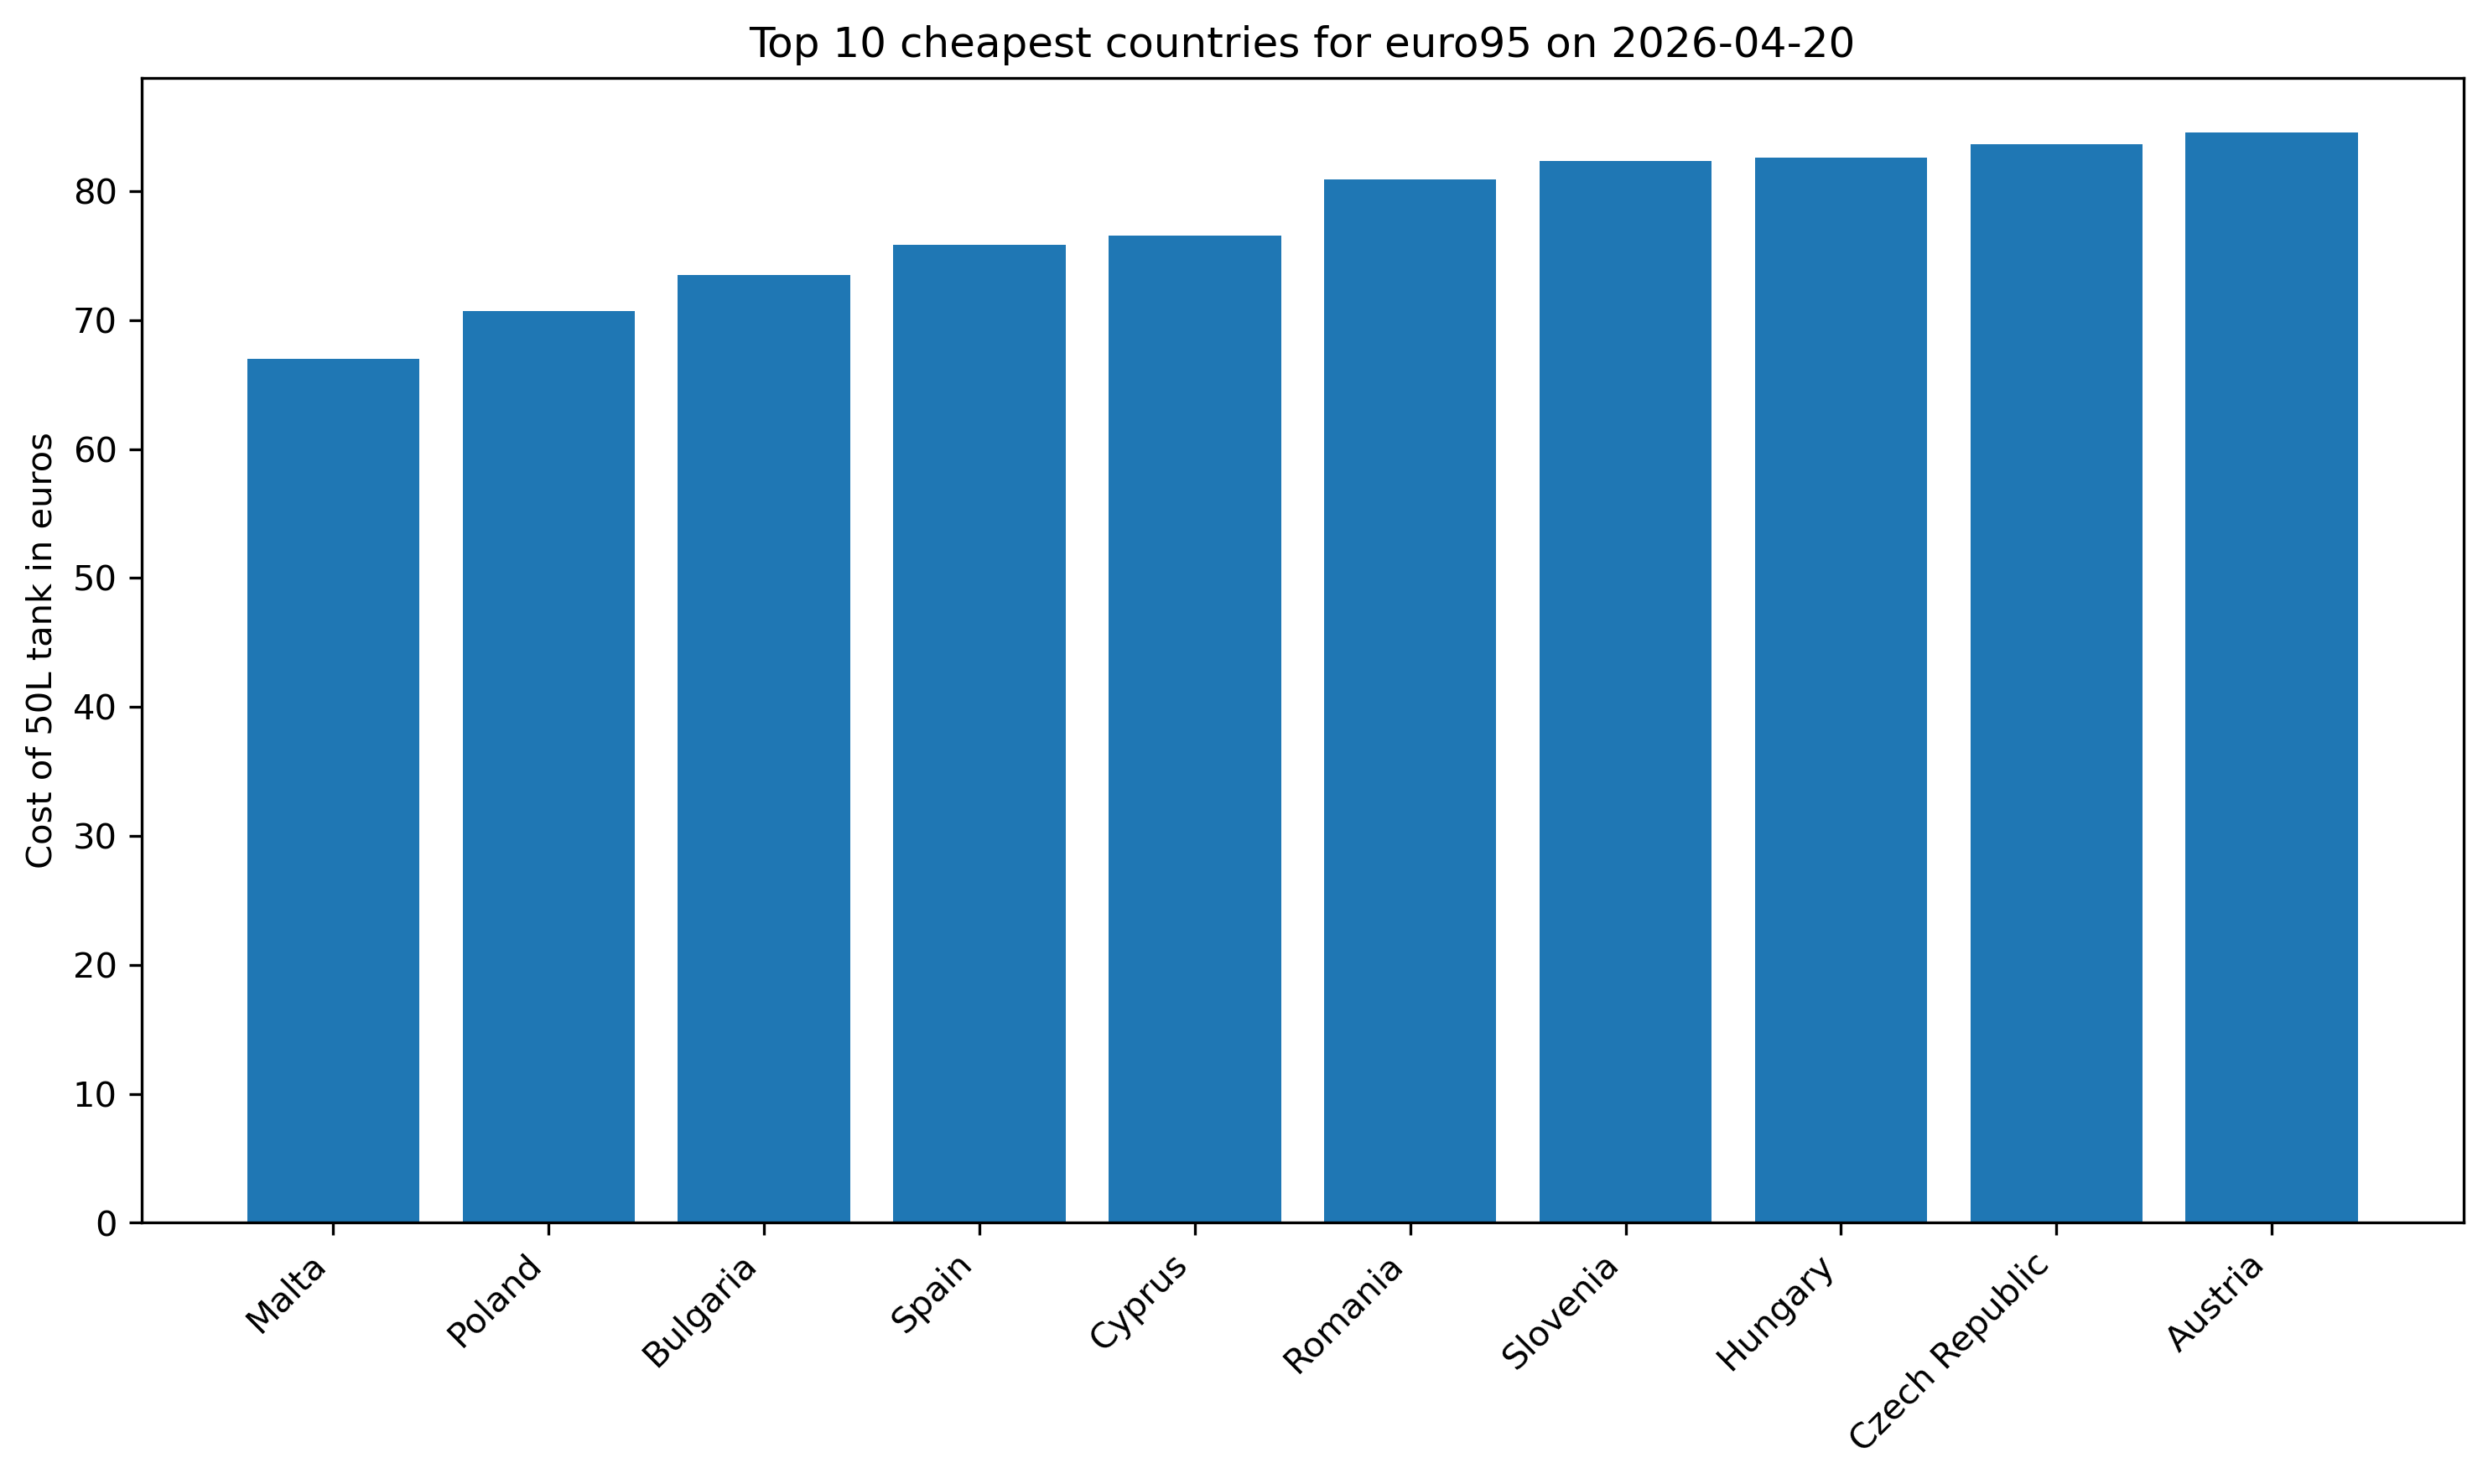

In [36]:
from IPython.display import Image, display
display(Image(filename="top10_euro95_latest.png"))

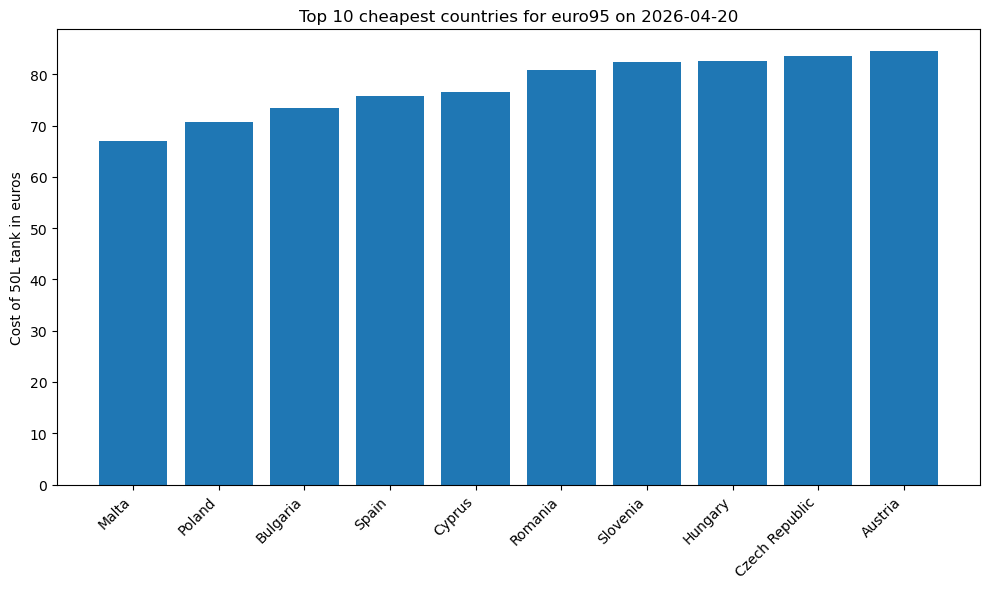

In [32]:
import matplotlib.pyplot as plt
from analysis import load_data, add_country_names, keep_eu_countries_only, get_latest_ranking

df = load_data()
df = add_country_names(df)
df = keep_eu_countries_only(df)

fuel_df, latest_date = get_latest_ranking(df, fuel_type="euro95", tank_size=50)
top10 = fuel_df.head(10)

plt.figure(figsize=(10, 6))
plt.bar(top10["country_name"], top10["tank_cost"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Cost of 50L tank in euros")
plt.title(f"Top 10 cheapest countries for euro95 on {latest_date.date()}")
plt.tight_layout()
plt.savefig("top10_euro95_latest.png", dpi=300, bbox_inches="tight")
plt.show()